<a href="https://colab.research.google.com/github/lbenit/Floristic_map_africa/blob/main/08_Cross_validation_4_clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/lbenit/Floristic_map_africa.git


Cloning into 'Floristic_map_africa'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.35 MiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd Floristic_map_africa


/content/Floristic_map_africa/Floristic_map_africa


In [ ]:
# Print working directory
import os
print(os.getcwd())

/content/Floristic_map_africa/Floristic_map_africa


In [3]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Load in data

In [5]:
# Combine test and train
all_data=pd.read_csv('Data/plot_data_with_all_variables.csv')

In [6]:
# Environmental variables
predictors= ['fire_frequency','EVI_mean', 'EVI_median', 'EVI_max', 'EVI_min', 'EVI_stdDev', 'EVI_p5', 'EVI_p95', 'B9_mean', 'B9_median', 'B9_max', 'B9_min', 'B9_stdDev', 'B9_p5', 'B9_p95', 'B11_mean', 'B11_median', 'B11_max', 'B11_min', 'B11_stdDev', 'B11_p5', 'B11_p95', 'B12_mean', 'B12_median', 'B12_max', 'B12_min', 'B12_stdDev', 'B12_p5', 'B12_p95', 'B1_mean', 'B1_median', 'B1_max', 'B1_min', 'B1_stdDev', 'B1_p5', 'B1_p95', 'B2_mean', 'B2_median', 'B2_max', 'B2_min', 'B2_stdDev', 'B2_p5', 'B2_p95', 'B3_mean', 'B3_median', 'B3_max', 'B3_min', 'B3_stdDev', 'B3_p5', 'B3_p95', 'B4_mean', 'B4_median', 'B4_max', 'B4_min', 'B4_stdDev', 'B4_p5', 'B4_p95', 'B5_mean', 'B5_median', 'B5_max', 'B5_min', 'B5_stdDev', 'B5_p5', 'B5_p95', 'B6_mean', 'B6_median', 'B6_max', 'B6_min', 'B6_stdDev', 'B6_p5', 'B6_p95', 'B7_mean', 'B7_median', 'B7_max', 'B7_min', 'B7_stdDev', 'B7_p5', 'B7_p95', 'B8_mean', 'B8_median', 'B8_max', 'B8_min', 'B8_stdDev', 'B8_p5', 'B8_p95','bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'Greenup', 'MidGreenup', 'Peak', 'Maturity', 'Senescence', 'MidGreendown', 'Dormancy', 'EVI_Minimum', 'EVI_Amplitude', 'EVI_Area', 'tpi', 'hnd','bd_mean_0_20', 'bd_mean_20_50', 'bd_stdev_0_20', 'bd_stdev_20_50', 'calcium_extractable_mean_0_20', 'calcium_extractable_mean_20_50', 'calcium_extractable_stdev_0_20', 'calcium_extractable_stdev_20_50', 'cec_mean_0_20', 'cec_mean_20_50', 'cec_stdev_0_20', 'cec_stdev_20_50', 'clay_mean_0_20', 'clay_mean_20_50', 'clay_stdev_0_20', 'clay_stdev_20_50', 'iron_extractable_mean_0_20', 'iron_extractable_mean_20_50', 'iron_extractable_stdev_0_20', 'iron_extractable_stdev_20_50', 'magnesium_extractable_mean_0_20', 'magnesium_extractable_mean_20_50', 'magnesium_extractable_stdev_0_20', 'magnesium_extractable_stdev_20_50', 'nitrogen_total_mean_0_20', 'nitrogen_total_mean_20_50', 'nitrogen_total_stdev_0_20', 'nitrogen_total_stdev_20_50', 'ph_mean_0_20', 'ph_mean_20_50', 'ph_stdev_0_20', 'ph_stdev_20_50', 'phosphorus_extractable_mean_0_20', 'phosphorus_extractable_mean_20_50', 'phosphorus_extractable_stdev_0_20', 'phosphorus_extractable_stdev_20_50', 'potassium_extractable_mean_0_20', 'potassium_extractable_mean_20_50', 'potassium_extractable_stdev_0_20', 'potassium_extractable_stdev_20_50', 'sand_mean_0_20', 'sand_mean_20_50', 'sand_stdev_0_20', 'sand_stdev_20_50', 'silt_mean_0_20', 'silt_mean_20_50', 'silt_stdev_0_20', 'silt_stdev_20_50', 'soc_mean_0_20', 'soc_mean_20_50', 'soc_stdev_0_20', 'soc_stdev_20_50', 'sulfur_extractable_mean_0_20', 'sulfur_extractable_mean_20_50', 'sulfur_extractable_stdev_0_20', 'sulfur_extractable_stdev_20_50', 'zinc_extractable_mean_0_20', 'zinc_extractable_mean_20_50', 'zinc_extractable_stdev_0_20', 'zinc_extractable_stdev_20_50']

In [7]:
# get length
len(predictors)

176

In [8]:
# See balance between clusters
all_data['cluster4'].value_counts()

,count
cluster4,
1,159
0,125
2,60
3,22


In [9]:
# Get number of unique plot_id in all_data
len(all_data['plot_id'].unique())

366

# Cross validation

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, precision_score,
    recall_score, f1_score, confusion_matrix
)



In [ ]:
# Basic predicters
predictors=['bio12','bio4','bio16','hnd','fire_frequency','bio1','cec_mean_0_20']

In [11]:
# CHoose target
# CHange as necessary
targets = ["cluster4"]

In [12]:
df = all_data

In [13]:
# Set random forest parameters

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


In [14]:
# Normal cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for target in targets:
    X = df[predictors].values
    y = df[target].values

    # Cross‑validated predictions (like caret)
    y_pred = cross_val_predict(clf, X, y, cv=cv)

    # Metrics
    acc  = accuracy_score(y, y_pred)
    kap  = cohen_kappa_score(y, y_pred)
    prec = precision_score(y, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y, y_pred, average="weighted")
    f1   = f1_score(y, y_pred, average="weighted")

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)

    results[target] = {
        "Accuracy": acc,
        "Kappa": kap,
        "Precision_weighted": prec,
        "Recall_weighted": rec,
        "F1_weighted": f1,
        "Confusion_matrix": cm
    }

results


{'cluster4': {'Accuracy': 0.7595628415300546,
  'Kappa': np.float64(0.6310145724498213),
  'Precision_weighted': 0.7191797998996858,
  'Recall_weighted': 0.7595628415300546,
  'F1_weighted': 0.7384684349131609,
  'Confusion_matrix': array([[ 85,  24,  13,   3],
         [ 13, 144,   2,   0],
         [ 11,   0,  49,   0],
         [ 17,   0,   5,   0]])}}

# Spatial block cross validation

In [15]:
def spatial_block_cv(
    df, predictors, target, xcol, ycol,
    n_splits_x=3, n_splits_y=3,
    random_state=42
):
    df = df.copy()

    # ---------------------------------------------------------
    # 1. Create spatial blocks using quantile cuts
    # ---------------------------------------------------------
    df["x_block"] = pd.qcut(df[xcol], n_splits_x, labels=False, duplicates="drop")
    df["y_block"] = pd.qcut(df[ycol], n_splits_y, labels=False, duplicates="drop")

    df["block"] = df["x_block"] * n_splits_y + df["y_block"]

    # Shuffle block order
    blocks = df["block"].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(blocks)

    # ---------------------------------------------------------
    # 2. Storage
    # ---------------------------------------------------------
    y_true_all = []
    y_pred_all = []

    # ---------------------------------------------------------
    # 3. Loop over blocks
    # ---------------------------------------------------------
    for test_block in blocks:
        test_mask = df["block"] == test_block
        train_mask = df["block"] != test_block

        # Skip blocks that produce empty train or test sets
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_train = df.loc[train_mask, predictors].values
        y_train = df.loc[train_mask, target].values
        X_test  = df.loc[test_mask, predictors].values
        y_test  = df.loc[test_mask, target].values

        clf = RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    # ---------------------------------------------------------
    # 4. Metrics
    # ---------------------------------------------------------
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    return {
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Kappa": cohen_kappa_score(y_true_all, y_pred_all),
        "F1_macro": f1_score(y_true_all, y_pred_all, average="macro"),
        "F1_weighted": f1_score(y_true_all, y_pred_all, average="weighted"),
        "Per_class_metrics": classification_report(
            y_true_all, y_pred_all, output_dict=True, zero_division=0
        ),
        "Confusion_matrix": confusion_matrix(y_true_all, y_pred_all),
        "df_with_blocks": df
    }


In [18]:
# Run spatial block
results = spatial_block_cv(
    df=all_data,
    predictors=predictors,
    target='cluster4',
    xcol="longitude_of_centre",
    ycol="latitude_of_centre"
)

results

{'Accuracy': 0.30601092896174864,
 'Kappa': np.float64(-0.050037273815709105),
 'F1_macro': 0.30580567844201717,
 'F1_weighted': 0.31421085926250153,
 'Per_class_metrics': {'0': {'precision': 0.22510822510822512,
   'recall': 0.416,
   'f1-score': 0.29213483146067415,
   'support': 125.0},
  '1': {'precision': 0.40860215053763443,
   'recall': 0.2389937106918239,
   'f1-score': 0.30158730158730157,
   'support': 159.0},
  '2': {'precision': 0.8181818181818182,
   'recall': 0.3,
   'f1-score': 0.43902439024390244,
   'support': 60.0},
  '3': {'precision': 0.2,
   'recall': 0.18181818181818182,
   'f1-score': 0.19047619047619047,
   'support': 22.0},
  'accuracy': 0.30601092896174864,
  'macro avg': {'precision': 0.41297304845691946,
   'recall': 0.2842029731275014,
   'f1-score': 0.30580567844201717,
   'support': 366.0},
  'weighted avg': {'precision': 0.40053874088776265,
   'recall': 0.30601092896174864,
   'f1-score': 0.31421085926250153,
   'support': 366.0}},
 'Confusion_matrix': 

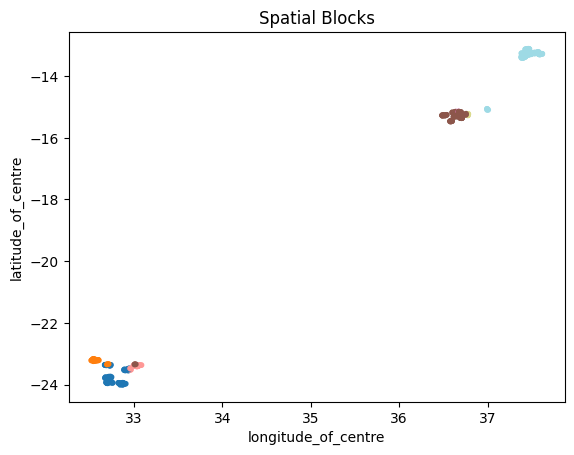

In [19]:

dfb = results["df_with_blocks"]

xcol="longitude_of_centre"
ycol="latitude_of_centre"

plt.scatter(dfb[xcol], dfb[ycol], c=dfb["block"], cmap="tab20", s=10)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title("Spatial Blocks")
plt.show()


# Cross validation by country
This won't work now because the sample data only has data from one country.

In [20]:
def country_cv(df, predictors, target, country_col, random_state=42):
    df = df.copy()
    countries = df[country_col].unique()

    results = []

    for country in countries:
        # Split data
        test_mask = df[country_col] == country
        train_mask = ~test_mask

        # Skip if country has no samples
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_train = df.loc[train_mask, predictors]
        y_train = df.loc[train_mask, target]
        X_test  = df.loc[test_mask, predictors]
        y_test  = df.loc[test_mask, target]

        # Model
        clf = RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1w = f1_score(y_test, y_pred, average="weighted")
        kappa = cohen_kappa_score(y_test, y_pred)

        results.append({
            "country": country,
            "n_test": len(y_test),
            "accuracy": acc,
            "f1_weighted": f1w,
            "kappa": kappa
        })

        print(f"{country}: accuracy={acc:.3f}, F1={f1w:.3f}, kappa={kappa:.3f}")

    return pd.DataFrame(results)


In [21]:
results = country_cv(
    df=all_data,
    predictors=predictors,
    target="cluster4",
    country_col="country_iso3"
)

print(results)


Empty DataFrame
Columns: []
Index: []


In [22]:
# Get mean accuracy
results["accuracy"].mean()

KeyError: 'accuracy'

# Spatial stratefied k-fold

In [23]:
# Define spatially stratefied kfold

def spatial_stratified_kfold(
    gdf,
    predictors,
    target,
    country_col,
    cluster_col,
    n_splits=5,
    block_size_km=150,
    train_frac=0.7,
    random_state=None
):
    """
    Spatial K-fold CV with:
      - equal-area spatial blocks (~150 km)
      - country-preserving splits
      - 70/30 per-country sampling
      - guaranteed cluster coverage in each fold
    """

    if random_state is not None:
        np.random.seed(random_state)

    # --- 1. Project to a metric CRS (Africa Albers Equal Area) ---

    df = gdf.copy()

    # Extract coordinates in metres
    df["x"] = df.geometry.x
    df["y"] = df.geometry.y

    # --- 2. Build equal-area spatial blocks ---
    block_size_m = block_size_km * 1000

    df["x_block"] = (df["x"] // block_size_m).astype(int)
    df["y_block"] = (df["y"] // block_size_m).astype(int)
    df["block"] = df["x_block"] * 10_000 + df["y_block"]

    blocks = df["block"].unique()
    np.random.shuffle(blocks)

    # Assign blocks to folds
    block_to_fold = {b: i % n_splits for i, b in enumerate(blocks)}
    df["fold"] = df["block"].map(block_to_fold)

    folds = []

    # --- 3. Build folds ---
    for fold_id in range(n_splits):

        # Test = all points in the fold's blocks
        test_mask = df["fold"] == fold_id
        train_mask = ~test_mask

        train_idx = []
        test_idx = []

        # --- 4. 70/30 split inside each country ---
        for country, df_country in df.groupby(country_col):

            df_train_side = df_country[~df_country["fold"].eq(fold_id)]
            df_test_side  = df_country[df_country["fold"].eq(fold_id)]

            # Sample 70% of the training side
            if len(df_train_side) > 0:
                sampled_train = df_train_side.sample(
                    frac=train_frac, replace=False
                ).index
                train_idx.extend(sampled_train)
                test_idx.extend(df_train_side.drop(sampled_train).index)

            # All test-block points go to test
            test_idx.extend(df_test_side.index)

        train_idx = set(train_idx)
        test_idx = set(test_idx)

        # --- 5. Ensure all clusters appear in both sets ---
        all_clusters = set(df[cluster_col].unique())
        train_clusters = set(df.loc[list(train_idx), cluster_col])
        test_clusters  = set(df.loc[list(test_idx), cluster_col])

        missing_train = all_clusters - train_clusters
        missing_test  = all_clusters - test_clusters

        # Fix missing clusters in train
        for cl in missing_train:
            candidates = df[(df.index.isin(test_idx)) & (df[cluster_col] == cl)].index
            if len(candidates) > 0:
                move = candidates[0]
                test_idx.remove(move)
                train_idx.add(move)

        # Fix missing clusters in test
        for cl in missing_test:
            candidates = df[(df.index.isin(train_idx)) & (df[cluster_col] == cl)].index
            if len(candidates) > 0:
                move = candidates[0]
                train_idx.remove(move)
                test_idx.add(move)

        folds.append((train_idx, test_idx))

    return folds


In [24]:

def df_to_gdf(df, lon_col="lon", lat_col="lat"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # WGS84 lat/lon
    )
    return gdf


In [25]:
import geopandas as gpd

In [26]:
gdf = df_to_gdf(all_data, lon_col="longitude_of_centre", lat_col="latitude_of_centre")
gdf = gdf.set_crs("EPSG:4326")


In [27]:
# Convert to equal area
gdf_p= gdf.to_crs("EPSG:6933")



In [28]:
folds = spatial_stratified_kfold(
    gdf=gdf_p,
    predictors=predictors,
    target=target,
    country_col="country_iso3",
    cluster_col="cluster4",
    n_splits=5,
    block_size_km=150,
    train_frac=0.7,
    random_state=None   # leave None for different splits each run
)

for i, (train_idx, test_idx) in enumerate(folds):
    print(f"Fold {i}: train={len(train_idx)}, test={len(test_idx)}")


Fold 0: train=240, test=126
Fold 1: train=167, test=199
Fold 2: train=176, test=190
Fold 3: train=255, test=111
Fold 4: train=188, test=178


In [29]:
def evaluate_spatial_folds(gdf, folds, predictors, target):
    y_true_all = []
    y_pred_all = []

    for i, (train_idx, test_idx) in enumerate(folds):
        print(f"Running fold {i}...")

        # Extract train/test sets
        X_train = gdf.loc[list(train_idx), predictors].values
        y_train = gdf.loc[list(train_idx), target].values

        X_test  = gdf.loc[list(test_idx), predictors].values
        y_test  = gdf.loc[list(test_idx), target].values

        # Train model
        clf = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)

        # Predict
        y_pred = clf.predict(X_test)

        # Store results
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    # Convert to arrays
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    # Compute metrics
    results = {
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Kappa": cohen_kappa_score(y_true_all, y_pred_all),
        "F1_macro": f1_score(y_true_all, y_pred_all, average="macro"),
        "F1_weighted": f1_score(y_true_all, y_pred_all, average="weighted"),
        "Per_class_metrics": classification_report(
            y_true_all, y_pred_all, output_dict=True, zero_division=0
        ),
        "Confusion_matrix": confusion_matrix(y_true_all, y_pred_all)
    }

    return results


In [30]:
results = evaluate_spatial_folds(
    gdf=gdf_p,
    folds=folds,
    predictors=predictors,
    target="cluster4"
)

results

Running fold 0...
Running fold 1...
Running fold 2...
Running fold 3...
Running fold 4...


{'Accuracy': 0.6878109452736318,
 'Kappa': np.float64(0.514775257394842),
 'F1_macro': 0.5333707717104683,
 'F1_weighted': 0.6739310090735083,
 'Per_class_metrics': {'0': {'precision': 0.5742857142857143,
   'recall': 0.7003484320557491,
   'f1-score': 0.631083202511774,
   'support': 287.0},
  '1': {'precision': 0.8154761904761905,
   'recall': 0.791907514450867,
   'f1-score': 0.8035190615835777,
   'support': 346.0},
  '2': {'precision': 0.7,
   'recall': 0.6311475409836066,
   'f1-score': 0.6637931034482759,
   'support': 122.0},
  '3': {'precision': 0.125,
   'recall': 0.02040816326530612,
   'f1-score': 0.03508771929824561,
   'support': 49.0},
  'accuracy': 0.6878109452736318,
  'macro avg': {'precision': 0.5536904761904762,
   'recall': 0.5359529126888822,
   'f1-score': 0.5333707717104683,
   'support': 804.0},
  'weighted avg': {'precision': 0.6697758232646293,
   'recall': 0.6878109452736318,
   'f1-score': 0.6739310090735083,
   'support': 804.0}},
 'Confusion_matrix': arra

# Run classification with train and validation dataset
This allows you to compare the cross validation results with the results from the training and validation dataset

In [31]:
# Load in test train
embedding_test=pd.read_csv('Data/test_df.csv')
embedding_train=pd.read_csv('Data/train_df.csv')

In [32]:
# Predicters
predictors= ['EVI_mean', 'EVI_median', 'EVI_max', 'EVI_min', 'EVI_stdDev', 'EVI_p5', 'EVI_p95', 'B9_mean', 'B9_median', 'B9_max', 'B9_min', 'B9_stdDev', 'B9_p5', 'B9_p95', 'B11_mean', 'B11_median', 'B11_max', 'B11_min', 'B11_stdDev', 'B11_p5', 'B11_p95', 'B12_mean', 'B12_median', 'B12_max', 'B12_min', 'B12_stdDev', 'B12_p5', 'B12_p95', 'B1_mean', 'B1_median', 'B1_max', 'B1_min', 'B1_stdDev', 'B1_p5', 'B1_p95', 'B2_mean', 'B2_median', 'B2_max', 'B2_min', 'B2_stdDev', 'B2_p5', 'B2_p95', 'B3_mean', 'B3_median', 'B3_max', 'B3_min', 'B3_stdDev', 'B3_p5', 'B3_p95', 'B4_mean', 'B4_median', 'B4_max', 'B4_min', 'B4_stdDev', 'B4_p5', 'B4_p95', 'B5_mean', 'B5_median', 'B5_max', 'B5_min', 'B5_stdDev', 'B5_p5', 'B5_p95', 'B6_mean', 'B6_median', 'B6_max', 'B6_min', 'B6_stdDev', 'B6_p5', 'B6_p95', 'B7_mean', 'B7_median', 'B7_max', 'B7_min', 'B7_stdDev', 'B7_p5', 'B7_p95', 'B8_mean', 'B8_median', 'B8_max', 'B8_min', 'B8_stdDev', 'B8_p5', 'B8_p95','bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'Greenup', 'MidGreenup', 'Peak', 'Maturity', 'Senescence', 'MidGreendown', 'Dormancy', 'EVI_Minimum', 'EVI_Amplitude', 'EVI_Area', 'tpi', 'hnd','bd_mean_0_20', 'bd_mean_20_50', 'bd_stdev_0_20', 'bd_stdev_20_50', 'calcium_extractable_mean_0_20', 'calcium_extractable_mean_20_50', 'calcium_extractable_stdev_0_20', 'calcium_extractable_stdev_20_50', 'cec_mean_0_20', 'cec_mean_20_50', 'cec_stdev_0_20', 'cec_stdev_20_50', 'clay_mean_0_20', 'clay_mean_20_50', 'clay_stdev_0_20', 'clay_stdev_20_50', 'iron_extractable_mean_0_20', 'iron_extractable_mean_20_50', 'iron_extractable_stdev_0_20', 'iron_extractable_stdev_20_50', 'magnesium_extractable_mean_0_20', 'magnesium_extractable_mean_20_50', 'magnesium_extractable_stdev_0_20', 'magnesium_extractable_stdev_20_50', 'nitrogen_total_mean_0_20', 'nitrogen_total_mean_20_50', 'nitrogen_total_stdev_0_20', 'nitrogen_total_stdev_20_50', 'ph_mean_0_20', 'ph_mean_20_50', 'ph_stdev_0_20', 'ph_stdev_20_50', 'phosphorus_extractable_mean_0_20', 'phosphorus_extractable_mean_20_50', 'phosphorus_extractable_stdev_0_20', 'phosphorus_extractable_stdev_20_50', 'potassium_extractable_mean_0_20', 'potassium_extractable_mean_20_50', 'potassium_extractable_stdev_0_20', 'potassium_extractable_stdev_20_50', 'sand_mean_0_20', 'sand_mean_20_50', 'sand_stdev_0_20', 'sand_stdev_20_50', 'silt_mean_0_20', 'silt_mean_20_50', 'silt_stdev_0_20', 'silt_stdev_20_50', 'soc_mean_0_20', 'soc_mean_20_50', 'soc_stdev_0_20', 'soc_stdev_20_50', 'sulfur_extractable_mean_0_20', 'sulfur_extractable_mean_20_50', 'sulfur_extractable_stdev_0_20', 'sulfur_extractable_stdev_20_50', 'zinc_extractable_mean_0_20', 'zinc_extractable_mean_20_50', 'zinc_extractable_stdev_0_20', 'zinc_extractable_stdev_20_50']

In [33]:
# Filter all data to match embedding_test and embedding_train
embedding_test = all_data[all_data["plot_id"].isin(embedding_test["plot_id"].unique())]
embedding_train = all_data[all_data["plot_id"].isin(embedding_train["plot_id"].unique())]

In [34]:
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [35]:
def caret_style_evaluation(y_true, y_pred):
    overall_acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    # Per‑class metrics
    report = classification_report(
        y_true, y_pred,
        output_dict=True,
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Per‑class accuracy (diagonal / row sum)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    return {
        "Overall_Accuracy": overall_acc,
        "Kappa": kappa,
        "Per_Class_Accuracy": per_class_acc,
        "Classification_Report": report,
        "Confusion_Matrix": cm
    }


In [36]:

X_train = embedding_train[predictors]
y_train = embedding_train["cluster4"]

X_test  = embedding_test[ predictors]
y_test  = embedding_test["cluster4"]


# 2. Train RF
clf.fit(X_train, y_train)

# 3. Predict
y_pred = clf.predict(X_test)

# 4. Evaluate
results = caret_style_evaluation(y_test, y_pred)
results


{'Overall_Accuracy': 0.8,
 'Kappa': np.float64(0.673810486588489),
 'Per_Class_Accuracy': array([0.63157895, 0.94444444, 1.        , 0.        ]),
 'Classification_Report': {'0': {'precision': 0.8,
   'recall': 0.631578947368421,
   'f1-score': 0.7058823529411765,
   'support': 38.0},
  '1': {'precision': 0.8360655737704918,
   'recall': 0.9444444444444444,
   'f1-score': 0.8869565217391304,
   'support': 54.0},
  '2': {'precision': 0.6842105263157895,
   'recall': 1.0,
   'f1-score': 0.8125,
   'support': 13.0},
  '3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0},
  'accuracy': 0.8,
  'macro avg': {'precision': 0.5800690250215703,
   'recall': 0.6440058479532164,
   'f1-score': 0.6013347186700767,
   'support': 110.0},
  'weighted avg': {'precision': 0.7676570711428348,
   'recall': 0.8,
   'f1-score': 0.7752880144152522,
   'support': 110.0}},
 'Confusion_Matrix': array([[24, 10,  4,  0],
        [ 2, 51,  1,  0],
        [ 0,  0, 13,  0],
        [ 4,  0,  1,  

# Select best variables and rerun classification with top 25

In [37]:
# 1. Fit RF on all predictors to compute importance
clf_importance = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

clf_importance.fit(embedding_train[predictors], embedding_train["cluster4"])

# Extract importances
importances = clf_importance.feature_importances_
importance_df = pd.DataFrame({
    "feature": predictors,
    "importance": importances
}).sort_values("importance", ascending=False)


In [38]:
top25 = importance_df.head(25)["feature"].tolist()
print("Top 25 predictors:", top25)


Top 25 predictors: ['B2_p95', 'B3_p95', 'B12_p5', 'B1_p95', 'bio04', 'B5_p95', 'B4_p5', 'bio06', 'bd_mean_20_50', 'B12_max', 'B2_p5', 'calcium_extractable_mean_20_50', 'bio15', 'B6_median', 'bio16', 'B12_median', 'ph_mean_0_20', 'B3_p5', 'B7_p5', 'B9_p95', 'bio01', 'bio05', 'bio19', 'B11_max', 'bio07']


In [39]:
# Prepare reduced datasets
X_train = embedding_train[top25]
y_train = embedding_train["cluster4"]

X_test  = embedding_test[top25]
y_test  = embedding_test["cluster4"]

# Train RF again
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
results = caret_style_evaluation(y_test, y_pred)
results


{'Overall_Accuracy': 0.7909090909090909,
 'Kappa': np.float64(0.6634743282787976),
 'Per_Class_Accuracy': array([0.57894737, 0.94444444, 1.        , 0.2       ]),
 'Classification_Report': {'0': {'precision': 0.8148148148148148,
   'recall': 0.5789473684210527,
   'f1-score': 0.676923076923077,
   'support': 38.0},
  '1': {'precision': 0.8360655737704918,
   'recall': 0.9444444444444444,
   'f1-score': 0.8869565217391304,
   'support': 54.0},
  '2': {'precision': 0.6842105263157895,
   'recall': 1.0,
   'f1-score': 0.8125,
   'support': 13.0},
  '3': {'precision': 0.3333333333333333,
   'recall': 0.2,
   'f1-score': 0.25,
   'support': 5.0},
  'accuracy': 0.7909090909090909,
  'macro avg': {'precision': 0.6671060620586073,
   'recall': 0.6808479532163743,
   'f1-score': 0.6565948996655518,
   'support': 110.0},
  'weighted avg': {'precision': 0.7879264314121951,
   'recall': 0.7909090909090909,
   'f1-score': 0.7766475372453633,
   'support': 110.0}},
 'Confusion_Matrix': array([[22, 1